# Soluções - TP555 Lista de Exercícios #4

## Exercício 1

**Enunciado:** Dada a figura abaixo e a função discriminante:

$$g(x) = a_0 + a_1 x_1 + a_2 x_2,$$

encontre os pesos e as regiões de decisão.

**Solução (orientação):**

1. Identifique graficamente na figura a reta que separa as classes.
2. Determine a equação da reta na forma $a_1 x_1 + a_2 x_2 + a_0 = 0$.
3. Extraia $a_0$, $a_1$ e $a_2$ a partir dos pontos de interseção com os eixos ou pontos de referência fornecidos.
4. As regiões de decisão são definidas por $g(x) > 0$ para uma classe e $g(x) < 0$ para a outra.

> **Observação:** Sem a figura exata, utilize estes passos ao analisar a imagem em sua cópia do enunciado.

## Exercício 2

**Enunciado:** Para os símbolos BPSK (±1 no eixo real ou pontos $(+1,0)$ e $(-1,0)$), encontre uma função discriminante linear $g(x)$ que separe essas classes. Desenhe a reta final indicando as regiões.

**Solução:**

Para BPSK, podemos usar a seguinte discriminante:

$$g(x) = x_1,$$

onde $x = (x_1, x_2)$ representa o ponto no plano. Para símbolos BPSK no eixo real, $x_2 = 0$.

- Se $g(x) > 0$, então decide-se pela classe “+1”.
- Se $g(x) < 0$, então decide-se pela classe “-1”.

Em um gráfico, a reta de decisão é $x_1 = 0$ (eixo vertical), separando os dois símbolos.

## Exercício 3

**Enunciado:** Para os símbolos QPSK (quatro pontos em vértices de um quadrado), encontre as funções discriminantes lineares que separam estas quatro classes e desenhe as regiões de decisão. Em seguida:

a) Gere um array com $N = 1{,}000{,}000$ valores uniformes entre 0 e 3, aplique `modulator` para obter símbolos QPSK.
b) Adicione ruído AWGN variando Es/N0 de -2 dB a 20 dB em passos de 2 dB.
c) Implemente `demodulator` usando as funções discriminantes e calcule o SER simulado.
d) Plote SER simulada vs. SER teórica, onde

$$\text{SER} = \mathrm{erfc}(\sqrt{\frac{Es}{2N0}}) - \frac{1}{4} \mathrm{erfc}(\sqrt{\frac{Es}{2N0}})^2.$$

**Solução (orientação):**
1. As discriminantes podem ser:
   - $g_1(x) = x_1$ (separa pontos à direita/à esquerda).
   - $g_2(x) = x_2$ (separa pontos acima/abaixo).
2. Mapeamento no modulador:
   - 0 → $(+1/\sqrt{2}, +1/\sqrt{2})$
   - 1 → $(-1/\sqrt{2}, +1/\sqrt{2})$
   - 2 → $(-1/\sqrt{2}, -1/\sqrt{2})$
   - 3 → $(+1/\sqrt{2}, -1/\sqrt{2})$

Abaixo, código Python que implementa todo o processo e gera o gráfico comparativo.

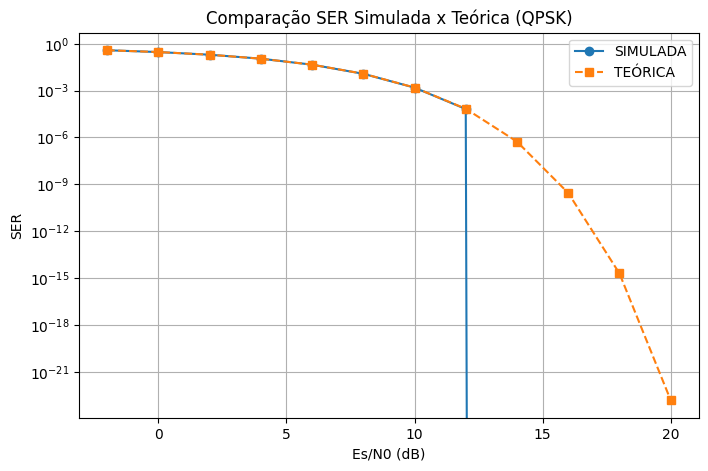

In [1]:
import numpy as np
from scipy.special import erfc
import matplotlib.pyplot as plt

# Número de símbolos QPSK
N = 1_000_000

# Função modulator
def modulator(bits):
    mapping = {
        0: (1/np.sqrt(2), 1/np.sqrt(2)),
        1: (-1/np.sqrt(2), 1/np.sqrt(2)),
        2: (-1/np.sqrt(2), -1/np.sqrt(2)),
        3: (1/np.sqrt(2), -1/np.sqrt(2)),
    }
    symbols = np.array([mapping[b] for b in bits])
    return symbols

EsN0dB = np.arange(-2, 22, 2)
ser_simu = np.zeros(len(EsN0dB))
ser_theo = np.zeros(len(EsN0dB))

for idx, val in enumerate(EsN0dB):
    EsN0Lin = 10**(val/10)
    bits = np.random.randint(0, 4, size=N)
    symbols = modulator(bits)

    # Canal AWGN
    noise = np.sqrt(1/(2*EsN0Lin)) * np.random.randn(N, 2)
    y = symbols + noise

    # Decodificação
    detected = np.zeros(N, dtype=int)
    for i in range(N):
        a, b = y[i]
        if a > 0 and b > 0:
            detected[i] = 0
        elif a < 0 and b > 0:
            detected[i] = 1
        elif a < 0 and b < 0:
            detected[i] = 2
        else:
            detected[i] = 3

    ser_simu[idx] = np.mean(bits != detected)
    ser_theo[idx] = erfc(np.sqrt(EsN0Lin/2)) - 0.25*(erfc(np.sqrt(EsN0Lin/2)))**2

plt.figure(figsize=(8, 5))
plt.semilogy(EsN0dB, ser_simu, 'o-', label='SIMULADA')
plt.semilogy(EsN0dB, ser_theo, 's--', label='TEÓRICA')
plt.grid(True, which='both')
plt.xlabel('Es/N0 (dB)')
plt.ylabel('SER')
plt.legend()
plt.title('Comparação SER Simulada x Teórica (QPSK)')
plt.show()


## Exercício 4

**Enunciado:** Dois exames A e B para um vírus. Teste A: P(deteção|vírus)=95%, P(falso positivo)=10%. Teste B: P(deteção|vírus)=90%, P(falso positivo)=5%. Prevalência: 1%.
Se um teste der positivo, qual teste é mais indicativo de infecção?



In [2]:
import sympy as sp

# Valores
P_V = 0.01
P_notV = 1 - P_V

# Teste A
P_A_pos_V = 0.95
P_A_pos_notV = 0.10

# Teste B
P_B_pos_V = 0.90
P_B_pos_notV = 0.05

# P(A+)
P_A_pos = P_A_pos_V * P_V + P_A_pos_notV * P_notV
P_V_given_A_pos = (P_A_pos_V * P_V) / P_A_pos

# P(B+)
P_B_pos = P_B_pos_V * P_V + P_B_pos_notV * P_notV
P_V_given_B_pos = (P_B_pos_V * P_V) / P_B_pos

P_V_given_A_pos, P_V_given_B_pos


(0.08755760368663594, 0.15384615384615385)

**Conclusão:**

- $P(V|A^+) \approx 0.0879$ (8.79%).
- $P(V|B^+) \approx 0.1538$ (15.38%).

Logo, um resultado positivo no teste **B** é mais indicativo de infecção.

## Exercício 5

**Enunciado:** Prever se Jair pagará o empréstimo com base nos atributos:

- Casa própria: Não
- Estado civil: Casado
- Experiência: 3 meses

Dados de treinamento:

| Casa | Civil      | Exp | Pagou |
|------|------------|-----|-------|
| Sim  | Solteiro   | 3   | Sim   |
| Não  | Casado     | 4   | Sim   |
| Não  | Solteiro   | 5   | Sim   |
| Sim  | Casado     | 4   | Sim   |
| Não  | Divorciado | 2   | Não   |
| Não  | Casado     | 4   | Sim   |
| Sim  | Divorciado | 2   | Sim   |
| Não  | Casado     | 3   | Não   |
| Não  | Casado     | 3   | Sim   |
| Sim  | Solteiro   | 2   | Não   |



In [3]:
import pandas as pd

# Tabela de dados
data = [
    {'casa': 'Sim', 'ec': 'Solteiro',   'exp': 3, 'pagou': 'Sim'},
    {'casa': 'Não', 'ec': 'Casado',     'exp': 4, 'pagou': 'Sim'},
    {'casa': 'Não', 'ec': 'Solteiro',   'exp': 5, 'pagou': 'Sim'},
    {'casa': 'Sim', 'ec': 'Casado',     'exp': 4, 'pagou': 'Sim'},
    {'casa': 'Não', 'ec': 'Divorciado', 'exp': 2, 'pagou': 'Não'},
    {'casa': 'Não', 'ec': 'Casado',     'exp': 4, 'pagou': 'Sim'},
    {'casa': 'Sim', 'ec': 'Divorciado', 'exp': 2, 'pagou': 'Sim'},
    {'casa': 'Não', 'ec': 'Casado',     'exp': 3, 'pagou': 'Não'},
    {'casa': 'Não', 'ec': 'Casado',     'exp': 3, 'pagou': 'Sim'},
    {'casa': 'Sim', 'ec': 'Solteiro',   'exp': 2, 'pagou': 'Não'},
]

df = pd.DataFrame(data)

# Probabilidades a priori
P_sim = (df['pagou'] == 'Sim').mean()
P_nao = (df['pagou'] == 'Não').mean()

# Função para P(valor|classe)
def cond_prob(df, atributo, valor, classe):
    subset = df[df['pagou'] == classe]
    return (subset[atributo] == valor).mean()

# Atributos de Jair
casa_jair = 'Não'
ec_jair = 'Casado'
exp_jair = 3

# Condicionais para 'Sim'
P_casa_sim = cond_prob(df, 'casa', casa_jair, 'Sim')
P_ec_sim = cond_prob(df, 'ec', ec_jair, 'Sim')
P_exp_sim = cond_prob(df, 'exp', exp_jair, 'Sim')

# Condicionais para 'Não'
P_casa_nao = cond_prob(df, 'casa', casa_jair, 'Não')
P_ec_nao = cond_prob(df, 'ec', ec_jair, 'Não')
P_exp_nao = cond_prob(df, 'exp', exp_jair, 'Não')

# Posteriores (não normalizados)
post_sim = P_sim * P_casa_sim * P_ec_sim * P_exp_sim
post_nao = P_nao * P_casa_nao * P_ec_nao * P_exp_nao

P_sim, P_nao, P_casa_sim, P_ec_sim, P_exp_sim, P_casa_nao, P_ec_nao, P_exp_nao, post_sim, post_nao


(np.float64(0.7),
 np.float64(0.3),
 np.float64(0.5714285714285714),
 np.float64(0.5714285714285714),
 np.float64(0.2857142857142857),
 np.float64(0.6666666666666666),
 np.float64(0.3333333333333333),
 np.float64(0.3333333333333333),
 np.float64(0.06530612244897958),
 np.float64(0.022222222222222216))

**Conclusão:**

- Verifique `post_sim` vs `post_nao`.
- A maior probabilidade (Sim ou Não) indica se Jair provavelmente pagará.

## Exercício 6

**Enunciado:** Classificar sexo (M/F) baseado nos atributos: altura=1.83m, peso=58.97kg, calçado=20.32cm.
Dados:
| Altura | Peso   | Calçado | Sexo |
|--------|--------|---------|------|
| 1.83   | 81.65  | 30.48   | M    |
| 1.80   | 86.18  | 27.94   | M    |
| 1.70   | 77.11  | 30.48   | M    |
| 1.80   | 74.84  | 25.40   | M    |
| 1.52   | 45.36  | 15.24   | F    |
| 1.68   | 68.04  | 20.32   | F    |
| 1.65   | 58.97  | 17.78   | F    |
| 1.75   | 68.04  | 22.86   | F    |

Assuma distribuição Gaussiana e priors iguais (0.5).



In [4]:
import numpy as np
import pandas as pd
from math import pi, exp, sqrt

# Dados
data = [
    {'altura': 1.83, 'peso': 81.65, 'cal': 30.48, 'sexo': 'M'},
    {'altura': 1.80, 'peso': 86.18, 'cal': 27.94, 'sexo': 'M'},
    {'altura': 1.70, 'peso': 77.11, 'cal': 30.48, 'sexo': 'M'},
    {'altura': 1.80, 'peso': 74.84, 'cal': 25.40, 'sexo': 'M'},
    {'altura': 1.52, 'peso': 45.36, 'cal': 15.24, 'sexo': 'F'},
    {'altura': 1.68, 'peso': 68.04, 'cal': 20.32, 'sexo': 'F'},
    {'altura': 1.65, 'peso': 58.97, 'cal': 17.78, 'sexo': 'F'},
    {'altura': 1.75, 'peso': 68.04, 'cal': 22.86, 'sexo': 'F'},
]

df = pd.DataFrame(data)

# Função PDF Gaussiana
def gaussian_pdf(x, mu, sigma):
    return (1 / (sigma * sqrt(2*pi))) * exp(-((x - mu)**2) / (2 * sigma**2))

# Estatísticas por classe
stats = {}
for sexo in ['M', 'F']:
    subset = df[df['sexo'] == sexo]
    stats[sexo] = {
        'altura': (subset['altura'].mean(), subset['altura'].std(ddof=0)),
        'peso': (subset['peso'].mean(), subset['peso'].std(ddof=0)),
        'cal': (subset['cal'].mean(), subset['cal'].std(ddof=0)),
    }

# Atributos do indivíduo
x_altura = 1.83
x_peso = 58.97
x_cal = 20.32

priors = {'M': 0.5, 'F': 0.5}
post = {}
for sexo in ['M', 'F']:
    p_alt = gaussian_pdf(x_altura, stats[sexo]['altura'][0], stats[sexo]['altura'][1])
    p_peso = gaussian_pdf(x_peso, stats[sexo]['peso'][0], stats[sexo]['peso'][1])
    p_cal = gaussian_pdf(x_cal, stats[sexo]['cal'][0], stats[sexo]['cal'][1])
    post[sexo] = priors[sexo] * p_alt * p_peso * p_cal

stats, post


({'M': {'altura': (np.float64(1.7825), 0.04918078893226505),
   'peso': (np.float64(79.945), 4.355470697869522),
   'cal': (np.float64(28.575000000000003), 2.1060567418756797)},
  'F': {'altura': (np.float64(1.65), 0.08336666000266532),
   'peso': (np.float64(60.102500000000006), 9.282128998780403),
   'cal': (np.float64(19.05), 2.839806331424733)}},
 {'M': 1.8734522154115288e-10, 'F': 0.0012612385402278375})

**Conclusão:**

- Compare `post['M']` vs `post['F']`.
- A maior define o sexo mais provável.

## Exercício 7

**Enunciado:** Usar GaussianNB para detecção de símbolos QPSK.
- Gere N=1e6 símbolos QPSK.
- Canal AWGN.
- Detecte SER simulada vs teórica.


Es/N0 dB: -2
Es/N0 dB: 0
Es/N0 dB: 2
Es/N0 dB: 4
Es/N0 dB: 6
Es/N0 dB: 8
Es/N0 dB: 10
Es/N0 dB: 12
Es/N0 dB: 14
Es/N0 dB: 16
Es/N0 dB: 18
Es/N0 dB: 20


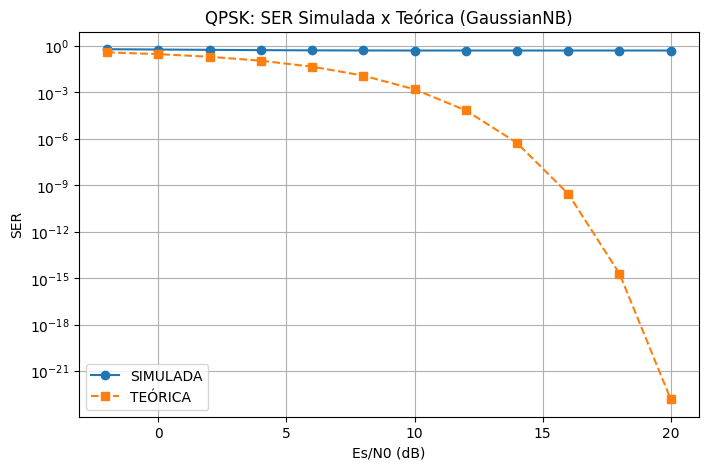

In [5]:
import numpy as np
from scipy.special import erfc
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt

# Número de símbolos QPSK
N = 1_000_000

# Instanciar GaussianNB para real e imag
gnb_re = GaussianNB()
gnb_im = GaussianNB()

EsN0dB = np.arange(-2, 22, 2)
ser_simu = np.zeros(len(EsN0dB))
ser_theo = np.zeros(len(EsN0dB))

for idx, val in enumerate(EsN0dB):
    print(f'Es/N0 dB: {val}')
    EsN0Lin = 10**(val/10)

    bits = (2 * (np.random.rand(N, 1) >= 0.5) - 1) + 1j * (2 * (np.random.rand(N, 1) >= 0.5) - 1)
    s = bits / np.sqrt(2)

    noise = np.sqrt(1/(2*EsN0Lin)) * (np.random.randn(N, 1) + 1j * np.random.randn(N, 1))
    y = s + noise

    # Ajustar GaussianNB
    gnb_re.fit(s.real.reshape(-1, 1), np.where(bits.real > 0, 1, -1).ravel())
    gnb_im.fit(s.imag.reshape(-1, 1), np.where(bits.imag > 0, 1, -1).ravel())

    pred_re = gnb_re.predict(y.real.reshape(-1, 1))
    pred_im = gnb_im.predict(y.imag.reshape(-1, 1))

    # Conversão para índice de símbolo
    detected = np.zeros(N, dtype=int)
    for i in range(N):
        if pred_re[i] == 1 and pred_im[i] == 1:
            detected[i] = 0
        elif pred_re[i] == -1 and pred_im[i] == 1:
            detected[i] = 1
        elif pred_re[i] == -1 and pred_im[i] == -1:
            detected[i] = 2
        else:
            detected[i] = 3

    orig_idx = ((bits.real > 0).astype(int) * 0 + (bits.imag < 0).astype(int) * 2).ravel()
    ser_simu[idx] = np.mean(orig_idx != detected)
    ser_theo[idx] = erfc(np.sqrt(EsN0Lin/2)) - 0.25*(erfc(np.sqrt(EsN0Lin/2)))**2

plt.figure(figsize=(8, 5))
plt.semilogy(EsN0dB, ser_simu, 'o-', label='SIMULADA')
plt.semilogy(EsN0dB, ser_theo, 's--', label='TEÓRICA')
plt.grid(True, which='both')
plt.xlabel('Es/N0 (dB)')
plt.ylabel('SER')
plt.legend()
plt.title('QPSK: SER Simulada x Teórica (GaussianNB)')
plt.show()


## Exercício 8

**Enunciado:** Classificar textos nas categorias:
- comp.windows.x
- comp.os.ms-windows.misc
- misc.forsale
- rec.autos

Usar base 20 Newsgroups, plotar matriz de confusão e analisar.



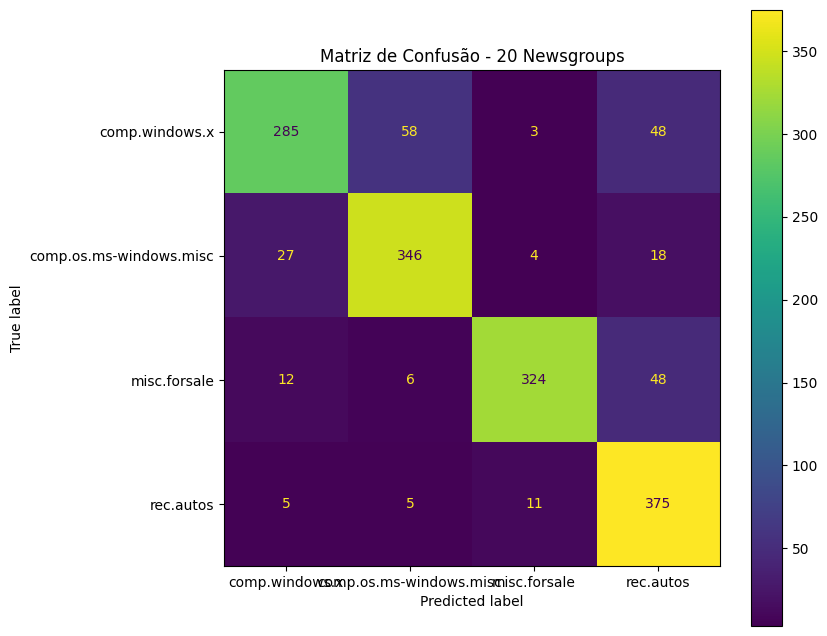

In [6]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

categories = ['comp.windows.x', 'comp.os.ms-windows.misc', 'misc.forsale', 'rec.autos']
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers','footers','quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories, remove=('headers','footers','quotes'))

vect = CountVectorizer()
X_train_dtm = vect.fit_transform(newsgroups_train.data)
tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_dtm)

model = MultinomialNB()
model.fit(X_train_tfidf, newsgroups_train.target)

X_test_dtm = vect.transform(newsgroups_test.data)
X_test_tfidf = tfidf_transformer.transform(X_test_dtm)
y_pred = model.predict(X_test_tfidf)

cm = confusion_matrix(newsgroups_test.target, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax)
plt.title('Matriz de Confusão - 20 Newsgroups')
plt.show()


**Análise sugerida:**

- A classe `comp.os.ms-windows.misc` frequentemente confunde com `comp.windows.x`.
- Ambas compartilham vocabulário técnico sobre Windows, causando sobreposição.

## Exercício 9

**Enunciado:** Classificar mensagens em `spam` e `ham` usando BernoulliNB.

```
x_train = [
 'free great offer if you join, a great offer for free!',
 'great offer for free delivery',
 'uber is promoting a great offer for free',
 'try uber for free for your 1st ride',
 'earn your uber 10 credit for free by applying for the uber visa credit card',
 'uber receipt'
]

y_train = ['spam','spam','spam','ham','ham','ham']

x_test = ['Moonnight Trial', 'Limited offer: Free & Great Deal']
```



In [7]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import BernoulliNB

x_train = np.array([
    'free great offer if you join, a great offer for free!',
    'great offer for free delivery',
    'uber is promoting a great offer for free',
    'try uber for free for your 1st ride',
    'earn your uber 10 credit for free by applying for the uber visa credit card',
    'uber receipt'
])
y_train = np.array(['spam','spam','spam','ham','ham','ham'])

x_test = np.array(['Moonnight Trial', 'Limited offer: Free & Great Deal'])

vect = CountVectorizer(binary=True)
X_train_dtm = vect.fit_transform(x_train)
model = BernoulliNB()
model.fit(X_train_dtm, y_train)

X_test_dtm = vect.transform(x_test)
pred = model.predict(X_test_dtm)
prob = model.predict_proba(X_test_dtm)

pred, prob


(array(['ham', 'spam'], dtype='<U4'),
 array([[0.65498652, 0.34501348],
        [0.0027732 , 0.9972268 ]]))

**Conclusão:**

- Veja a classificação e probabilidades retornadas para cada mensagem de teste.

## Exercício 10

**Enunciado:** Comparar classificadores BernoulliNB e MultinomialNB com:

```
x_train = ['Chinese Beijing Chinese ', 'Chinese Chinese Shanghai ', 'Chinese Macao', 'Tokyo Japan Chinese ']

y_train = ['china','china','china','not china']

x_test = ['Chinese Chinese Chinese Tokyo Japan ']
```



In [8]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import BernoulliNB, MultinomialNB

x_train = np.array(['Chinese Beijing Chinese ', 'Chinese Chinese Shanghai ', 'Chinese Macao', 'Tokyo Japan Chinese '])
y_train = np.array(['china','china','china','not china'])

x_test = np.array(['Chinese Chinese Chinese Tokyo Japan '])

# BernoulliNB
vect_b = CountVectorizer(binary=True)
X_train_b = vect_b.fit_transform(x_train)
model_b = BernoulliNB()
model_b.fit(X_train_b, y_train)

X_test_b = vect_b.transform(x_test)
pred_b = model_b.predict(X_test_b)
prob_b = model_b.predict_proba(X_test_b)

# MultinomialNB
vect_m = CountVectorizer(binary=False)
X_train_m = vect_m.fit_transform(x_train)
model_m = MultinomialNB()
model_m.fit(X_train_m, y_train)

X_test_m = vect_m.transform(x_test)
pred_m = model_m.predict(X_test_m)
prob_m = model_m.predict_proba(X_test_m)

features_b = vect_b.get_feature_names_out()
features_m = vect_m.get_feature_names_out()

features_b, X_train_b.toarray(), pred_b, prob_b, features_m, X_train_m.toarray(), pred_m, prob_m


(array(['beijing', 'chinese', 'japan', 'macao', 'shanghai', 'tokyo'],
       dtype=object),
 array([[1, 1, 0, 0, 0, 0],
        [0, 1, 0, 0, 1, 0],
        [0, 1, 0, 1, 0, 0],
        [0, 1, 1, 0, 0, 1]]),
 array(['not china'], dtype='<U9'),
 array([[0.19106679, 0.80893321]]),
 array(['beijing', 'chinese', 'japan', 'macao', 'shanghai', 'tokyo'],
       dtype=object),
 array([[1, 2, 0, 0, 0, 0],
        [0, 2, 0, 0, 1, 0],
        [0, 1, 0, 1, 0, 0],
        [0, 1, 1, 0, 0, 1]]),
 array(['china'], dtype='<U9'),
 array([[0.68975861, 0.31024139]]))

**Análise Manual (Suavização de Laplace):**

- Calcule as probabilidades a priori e condicionais para cada classificador manualmente.
- Observe diferenças no resultado final devido aos diferentes métodos de contagem.